# 7 - Classical Neo-Riemannian Transformations

## Import + Functions

In [163]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [708]:
%reload_ext autoreload
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import re

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia
from Importables import tonnetz_utils as t
from Importables import pitchanalysis_utils as pa

In [710]:
def update_chord_labels(df):
    exceptions = []
    labels_updated = []
    chord_updated = []
    
    for _, row in df.iterrows():
        tonic = row['globalkey']
        mode = 'minor' if row['globalkey_is_minor'] == 1 else 'major'
        k = m21.key.Key(tonic, mode)
        
        chord = row['chord']
        
        local_key_raw = row['localkey']
        local_mode = 'minor' if row['localkey_is_minor'] == 1 else 'major'
    
        local_key_chord = m21.roman.RomanNumeral(local_key_raw, k)
        local_tonic = local_key_chord.root()
    
        key = m21.key.Key(local_tonic, local_mode)
    
        rn = np.nan
        
        try:
            rn = m21.roman.RomanNumeral(chord, key)
            chord_updated.append(chord)
        except:
            try:
                numeral = row['numeral']
                rn = m21.roman.RomanNumeral(numeral, key)
                chord_updated.append(numeral)
                
            except:
                rn = np.nan
                chord_updated.append(numeral)
                exceptions.append({
                    "chord": row['chord'],
                    "numeral": row['numeral']
                })
            
    
        labels_updated.append(rn)
        
    df = df.copy()    
    df['label_updated'] = labels_updated
    df['chord_updated'] = chord_updated
    exceptions = pd.DataFrame(exceptions)

    return df, exceptions

In [627]:
def transformation(labels):
    rows_list = []
    exceptions = []
    
    for piece in labels['piece'].unique():
        subset = labels[labels['piece'] == piece]
        
        last_label = subset.iloc[0]['label_updated']
        last_label_name = subset.iloc[0]['chord_updated']
        for index, row in subset.iterrows():
                
            current_label = row['label_updated']
            current_label_name = row['chord_updated']
            # look for different label
            if (current_label_name != last_label_name):
                result = None
                l1 = l3 = l5 = c1 = c3 = c5 = None 
    
                try:
                    result = None
                    l1 = last_label.root()
                    l3 = last_label.third
                    l5 = last_label.fifth
                except:
                    transformation = 'N/A'
                    if current_label_name not in exceptions:
                        exceptions.append(last_label_name)
    
                try:
                    c1 = current_label.root()
                    c3 = current_label.third
                    c5 = current_label.fifth
                except:
                    transformation = 'N/A'
                    if current_label_name not in exceptions:
                        exceptions.append(current_label_name)
        
                if None in (l1, l3, l5, c1, c3, c5):
                    transformation = 'N/A'
                    
                elif current_label.isDiminishedTriad() or current_label.isAugmentedTriad():
                    transformation = 'N/A'
                    if current_label_name not in exceptions:
                        exceptions.append(current_label_name)
    
                elif last_label.isDiminishedTriad() or last_label.isAugmentedTriad():
                    transformation = 'N/A'
                    if last_label_name not in exceptions:
                        exceptions.append(last_label_name)
                    
                # Parallel Case   
                elif t.is_parallel(l1,l3,l5,c1,c3,c5):
                    transformation = 'P'
    
                # Relative Case 
                elif t.is_relative(l1,l3,l5,c1,c3,c5):
                    transformation = 'R'
                    
                # Leading-Tone Exchange Case 
                elif t.is_leading(l1,l3,l5,c1,c3,c5):
                    transformation = 'L'
    
            
                # Slide Case 
                elif t.is_slide(l1,l3,l5,c1,c3,c5):
                    transformation = 'S'
                    
                # Nebenverwandt Case
                elif t.is_nebenverwandt(l1,l3,l5,c1,c3,c5):
                    transformation = 'N'
    
                # Hexpole case
                elif t.is_hexpole(l1,l3,l5,c1,c3,c5):
                    transformation = 'H'
    
                else:
                    # Check two-step sequence
                    seq = find_two_step_sequence(last_label, current_label)
                    if seq is not None:
                        transformation = seq
                    else:
                        transformation = 'N/A'
    
                result = {'chord_1': last_label_name, 
                          'chord_2': current_label_name,
                          'transformation': transformation,
                          'piece': piece,
                          'year': row['year'],
                          'year_bin': row['year_bin']
                         }
                    
                rows_list.append(result)        
                last_label_name = current_label_name
                last_label = current_label
            
    df = pd.DataFrame(rows_list) 

    return df, exceptions
    

In [575]:
def find_two_step_sequence(chord1, chord2):
    transformations = {'P': t.P, 'R': t.R, 'L': t.L}

    for t1_name, t1_func in transformations.items():
        mid_chord = t1_func(chord1)

        if mid_chord is None:
            continue
        for t2_name, t2_func in transformations.items():
            mid_chord_copy = m21.chord.Chord([p for p in mid_chord.pitches])
            final_chord = t2_func(mid_chord_copy)
            if final_chord is None:
                continue
            try:
                if (final_chord.root().name == chord2.root().name and
                    final_chord.third.name == chord2.third.name and
                    final_chord.fifth.name == chord2.fifth.name):
                    return t1_name + t2_name
            except AttributeError:
                continue  # skip chords with missing components

    return None

In [527]:
def plot(df, transformation, bin_labels, y='Percent'):
    P_results = []
    
    for years in bin_labels:
        subset_year = df[df['year_bin'] == years]
        tot_count = subset_year.shape[0]
        # bootstrap
        sample_mean = []
        for i in range(100):
            sub_samp = subset_year.sample(frac=1, replace=True)
            if isinstance(transformation, str):
                P_count = sub_samp[sub_samp['transformation'] == transformation].shape[0]
            if isinstance(transformation, list):
                P_count = sub_samp[sub_samp['transformation'].isin(transformation)].shape[0]

            if y == 'Percent':
                if tot_count == 0:
                    avg = 0
                else:
                    avg = 100 * P_count / tot_count
                sample_mean.append(avg)
            if y == 'Count':
                sample_mean.append(P_count)
    
        mean_estimate = np.mean(sample_mean)
        ci_lower = np.percentile(sample_mean, 2.5)
        ci_upper = np.percentile(sample_mean, 97.5)
    
        P_results.append({
            'year_bin': years,
            'mean': mean_estimate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })
        
    P_results = pd.DataFrame(P_results)
    
    yerr = [
        P_results['mean'] - P_results['ci_lower'],
        P_results['ci_upper'] - P_results['mean']
    ]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.errorbar(P_results['year_bin'], P_results['mean'], yerr=yerr, capsize=5, color='skyblue')
    
    ax.set_xlabel('Year')
    if y == 'Percent':
        ax.set_ylabel(f'% of {transformation} Transformations')
    if y == 'Count':
        ax.set_ylabel(f'Count of {transformation} Transformations')
        
    ax.set_title(f'Bootstrap Estimates of {transformation} Transformation Proportions with 95% CIs')
    #ax.set_ylim(0, 100)
    ax.set_xticklabels(P_results['year_bin'], rotation=45)
    
    plt.tight_layout()
    plt.savefig(f"../Results/{transformation}Transformation")
    plt.show()

    return P_results['mean']

## Mozart

In [478]:
mozart_metadata = pd.read_csv("/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/mozart_piano_sonatas/metadata.tsv", sep='\t')

In [480]:
mozart = []
for _, row in mozart_metadata.iterrows():
    piece = row['piece']
    path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/mozart_piano_sonatas/harmonies/' + piece +'.harmonies.tsv'
    
    try:
        piece_df = pd.read_csv(path, sep='\t')
        piece_df['piece'] = piece
        piece_df['year'] = row['composed_start']
        mozart.append(piece_df)
    except:
        continue

mozart = pd.concat(mozart, ignore_index=True)

In [498]:
mozart_bins = np.arange(1770, 1791, 10) 
mozart_bin_labels = [f"{start}-{start+10}" for start in mozart_bins[:-1]]
mozart['year'] = pd.to_numeric(mozart['year'], errors='coerce')
mozart['year_bin'] = pd.cut(mozart['year'], bins=mozart_bins, labels=mozart_bin_labels, right=False)

In [505]:
mozart_updated, mozart_exceptions = update_chord_labels(mozart)
mozart_transformations, mozart_transform_exceptions = transformation(mozart_updated)

In [506]:
mozart_exceptions

,chord,numeral
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
237,NaN,NaN
238,NaN,NaN
239,NaN,NaN
240,NaN,NaN


In [507]:
mozart_NA = mozart_transformations[mozart_transformations['transformation'] == 'N/A'].copy()
print(mozart_NA.shape[0])
mozart_NA.value_counts(subset=['chord_1', 'chord_2']).reset_index(name='count').head(15) 

5914


,chord_1,chord_2,count
0,ii6,V,348
1,I6,ii6,173
2,I,ii6,145
3,IV,V,127
4,viio6,I6,93
5,viio6,I,92
6,viio7/V,V,82
7,I,viio6,81
8,viio,I,78
9,ii,V,66


In [508]:
mozart_transformations_cut = mozart_transformations[mozart_transformations['transformation'] != 'N/A'].copy()

<function matplotlib.pyplot.show(close=None, block=None)>

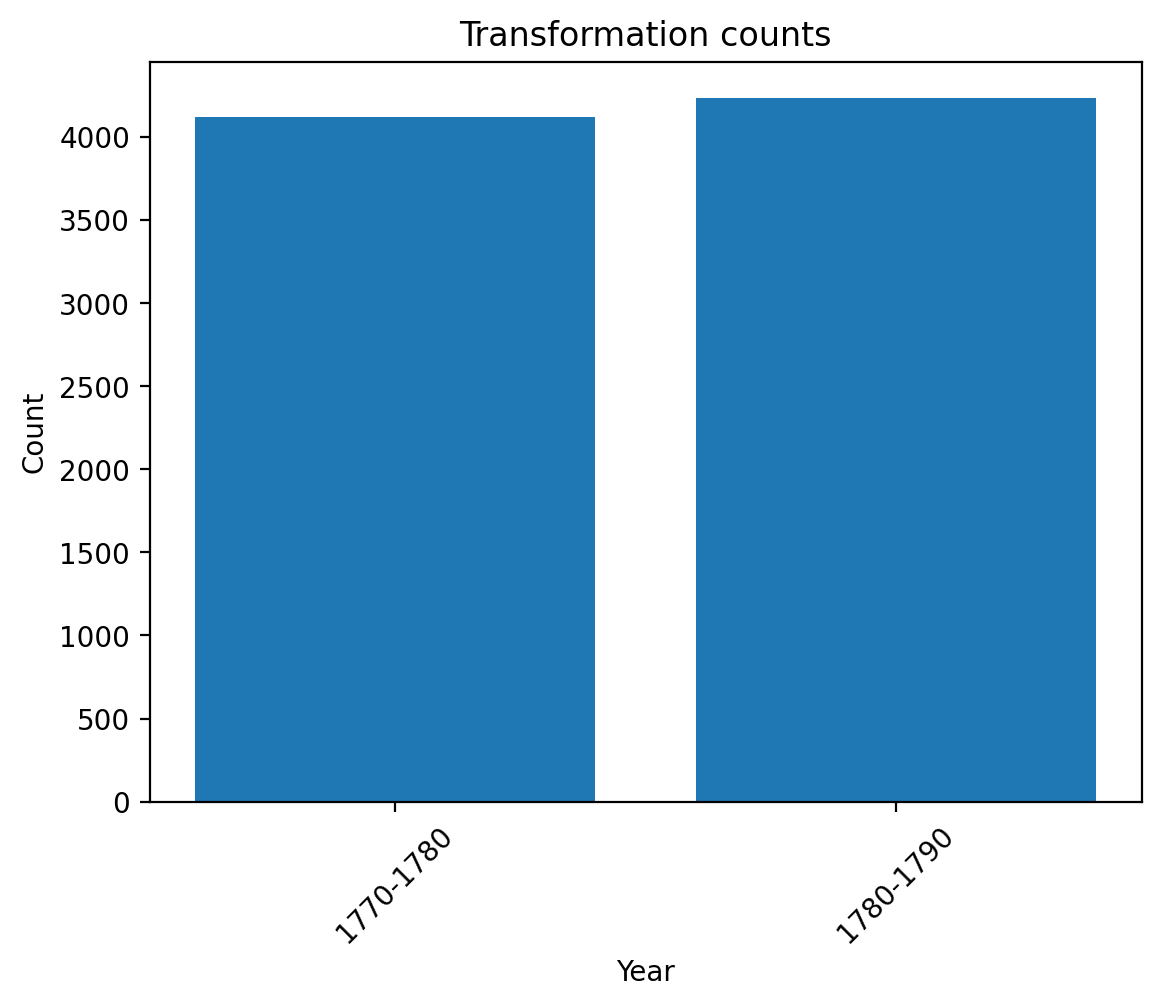

In [509]:
counts = mozart_transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
y = counts['count']
x = counts['year_bin'] 
plt.bar(x, y)
plt.title('Transformation counts')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(x,rotation=45)
plt.show

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_93475/1069552246.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


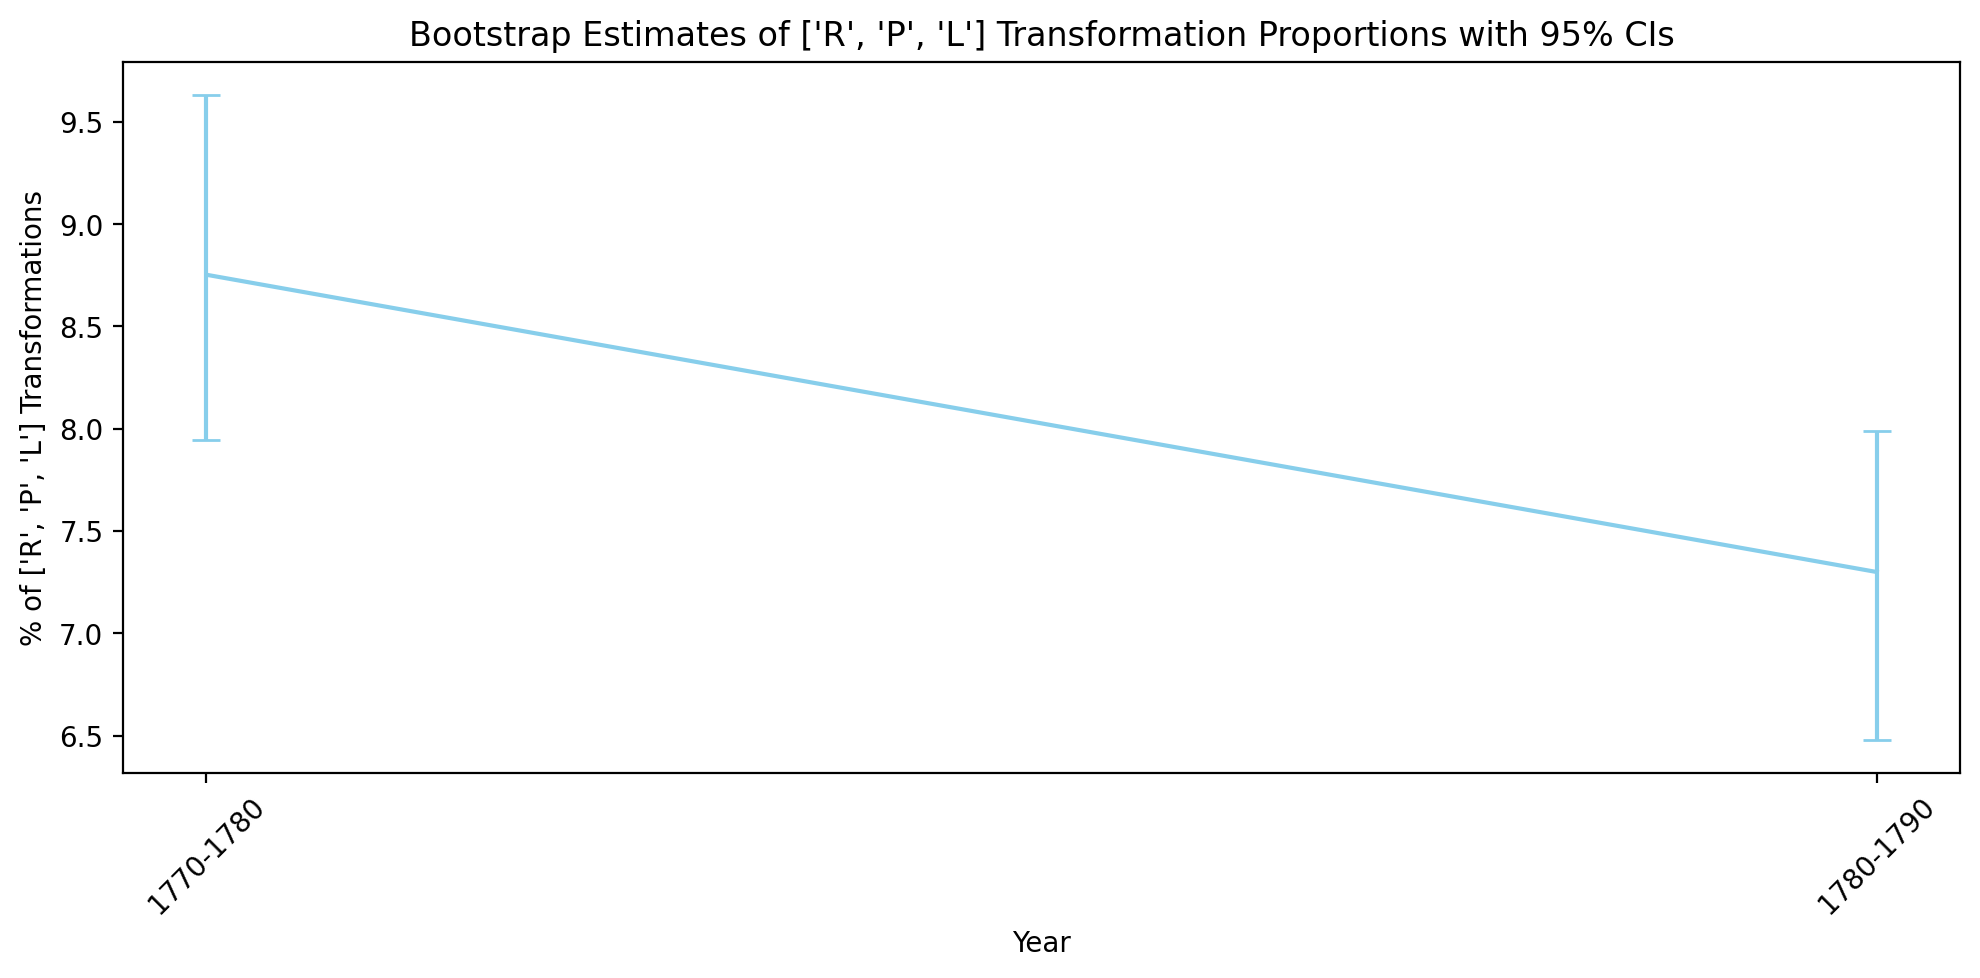

In [529]:
RPL = plot(mozart_transformations_cut, ['R','P','L'], mozart_bin_labels)

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_93475/1069552246.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


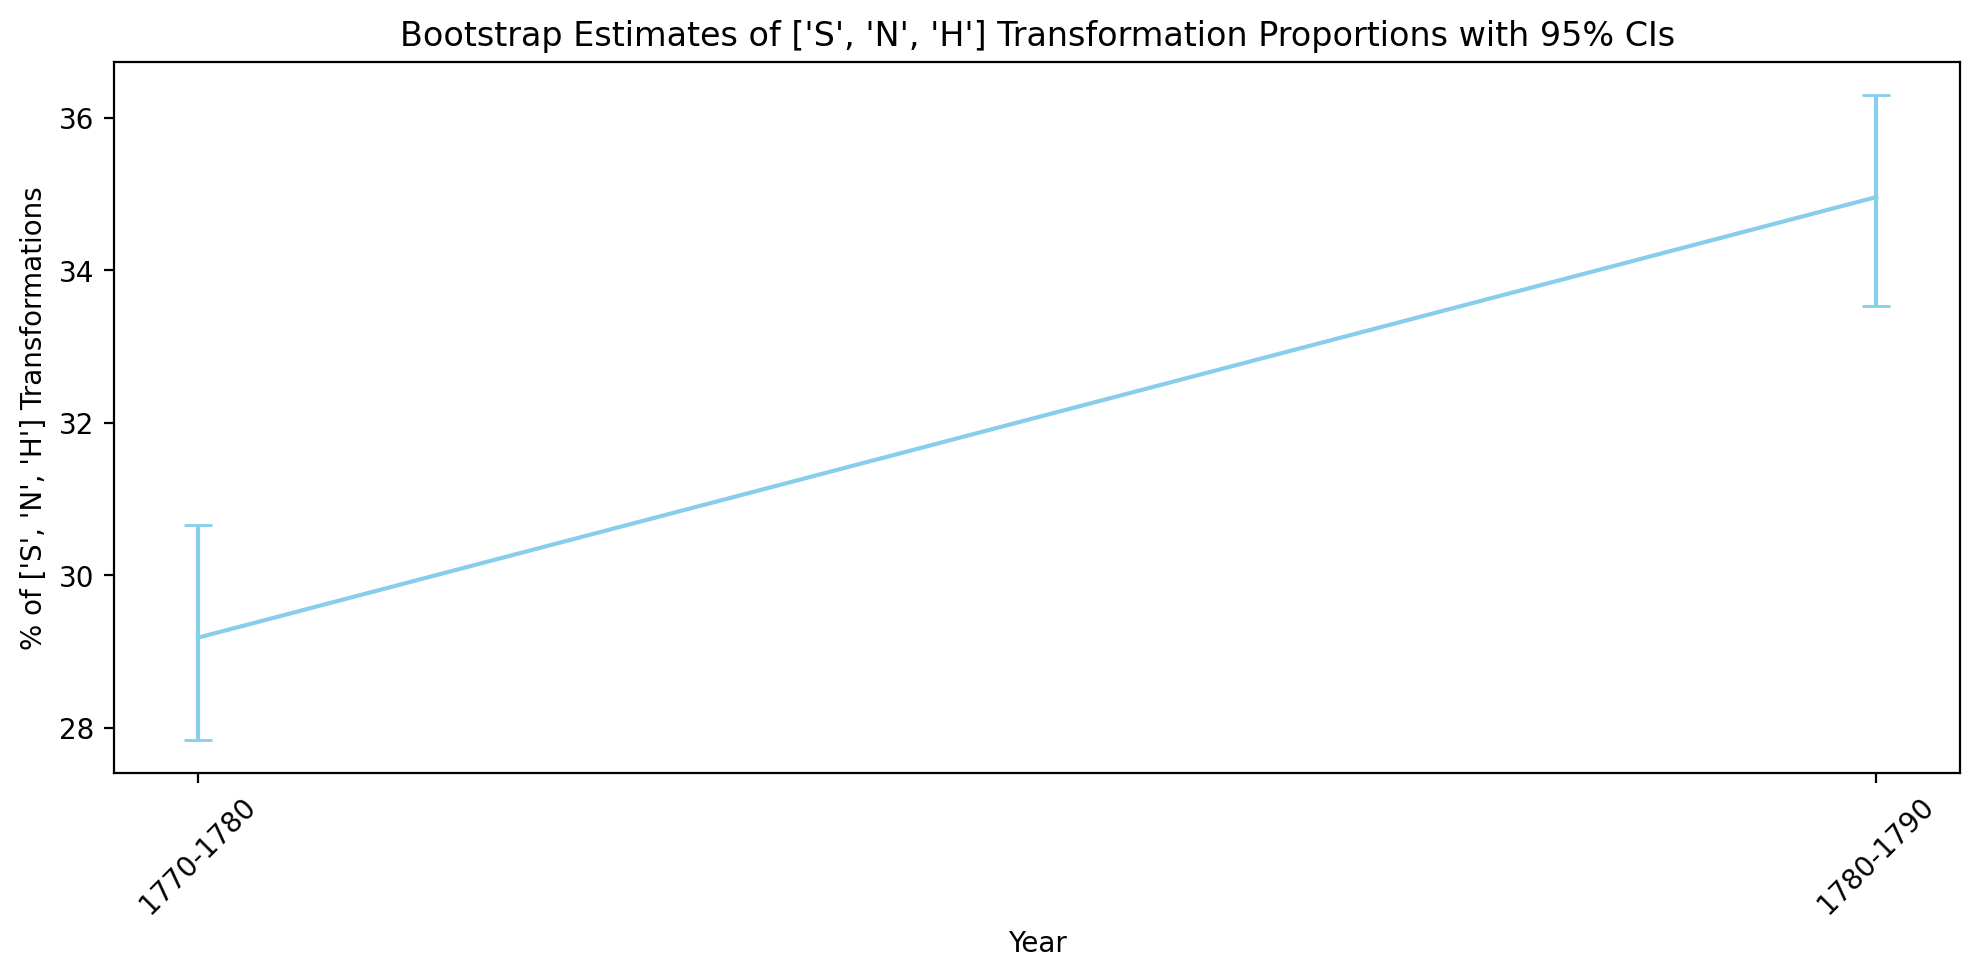

In [531]:
SNH = plot(mozart_transformations_cut, ['S','N','H'], mozart_bin_labels)

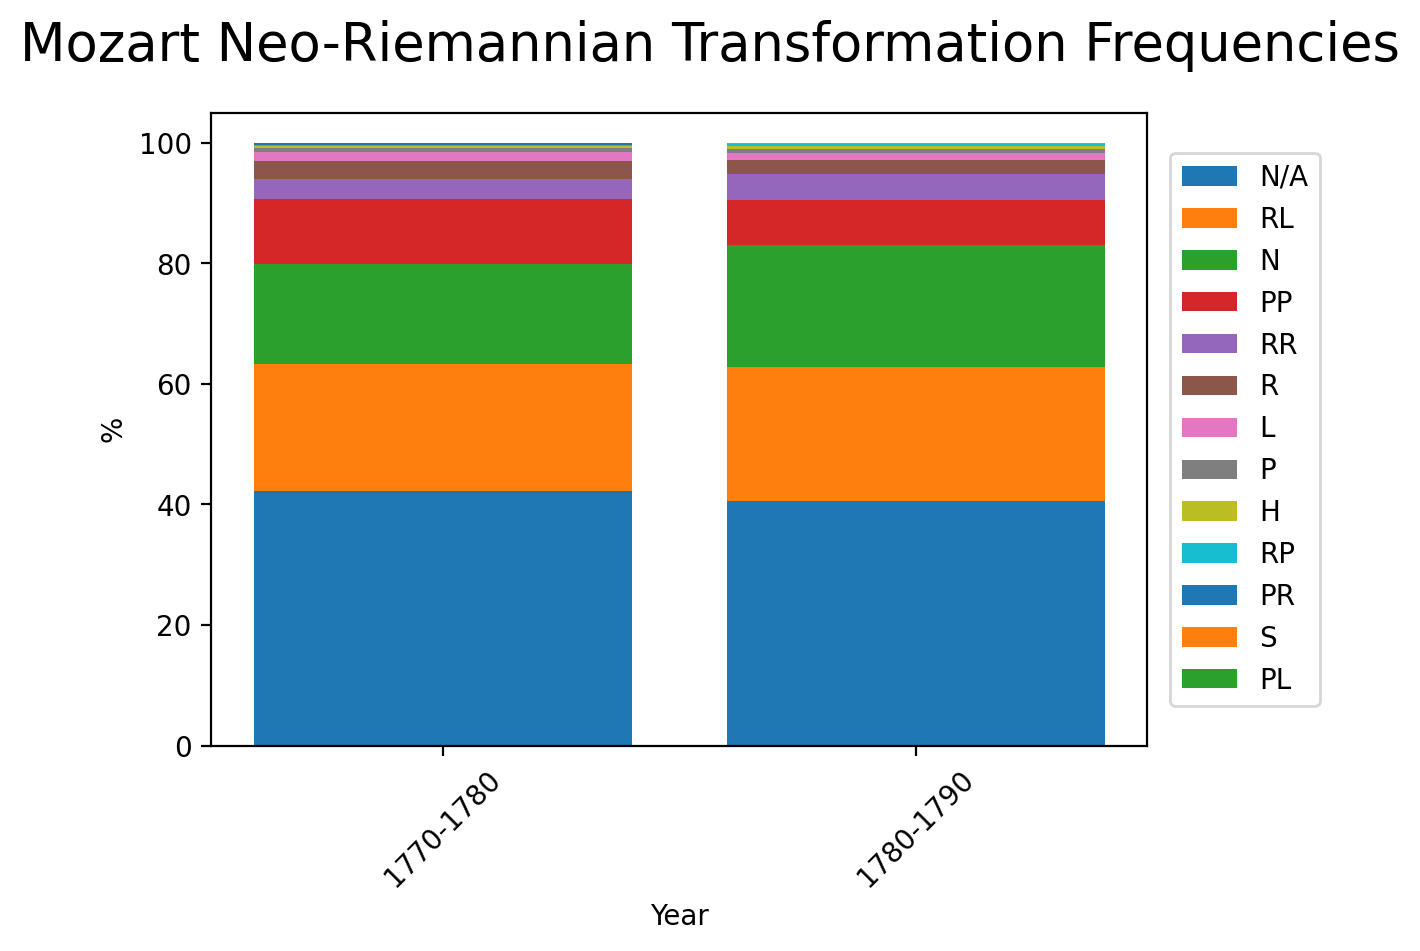

In [581]:
x = mozart_bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)
counts = mozart_transformations.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
tot_counts = (
    mozart_transformations.groupby('year_bin')
    .size()
    .reindex(x, fill_value=0)
)

for trans in mozart_transformations.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = mozart_transformations[mozart_transformations['transformation']== trans]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y) * 100/tot_counts

    ax.bar(x, y, bottom = current_itn, label=trans)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Mozart Neo-Riemannian Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.savefig(f"../Results/Mozart_Transformations")
plt.show()

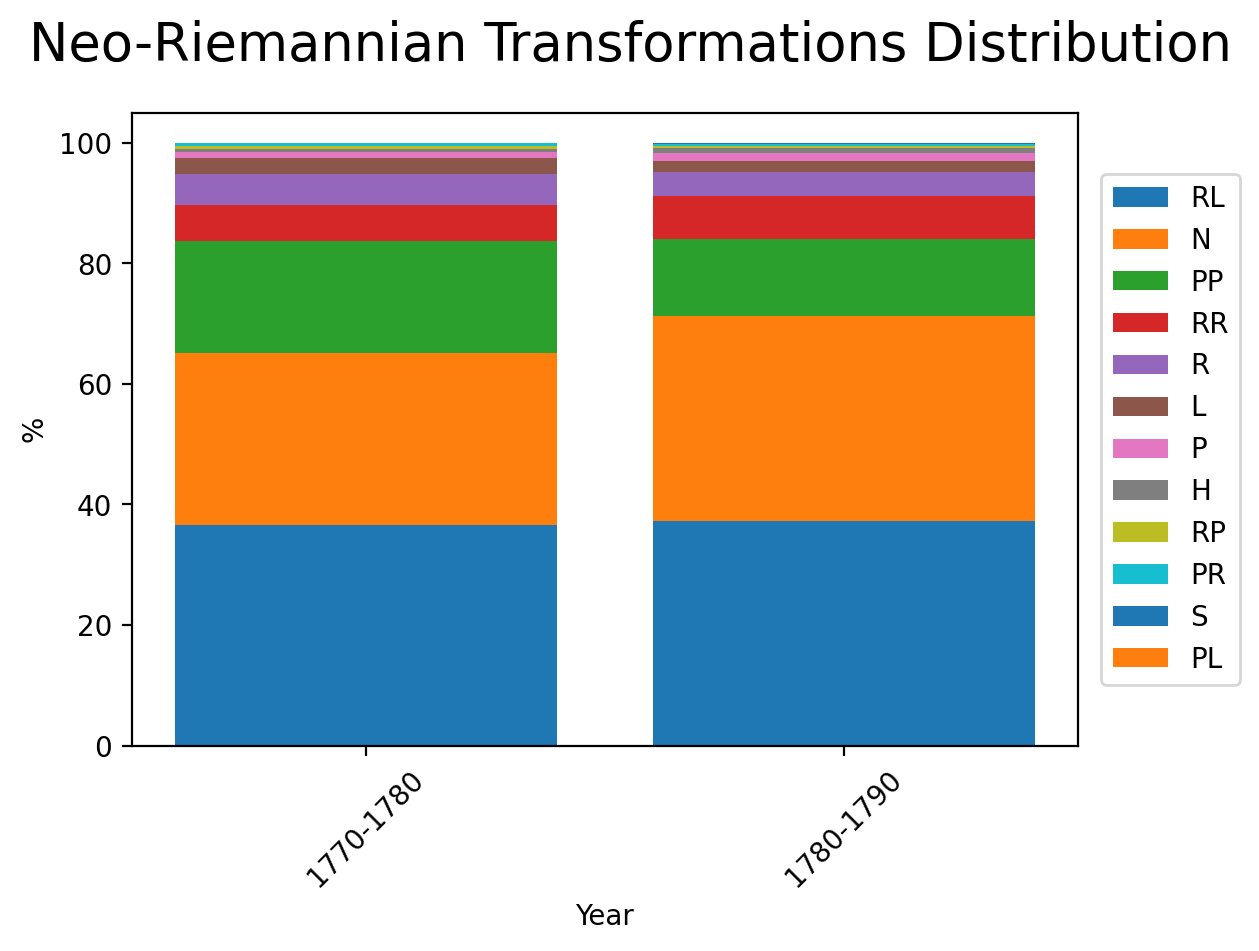

In [537]:
x = mozart_bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)
counts = mozart_transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
tot_counts = (
    mozart_transformations_cut.groupby('year_bin')
    .size()
    .reindex(x, fill_value=0)
)

for t in mozart_transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = mozart_transformations_cut[mozart_transformations_cut['transformation']== t]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y) * 100/tot_counts

    ax.bar(x, y, bottom = current_itn, label=t)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Distribution', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()

## Beethoven

In [545]:
beethoven_metadata = pd.read_csv("/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/beethoven_piano_sonatas/metadata.tsv", sep='\t')

In [547]:
beethoven = []
for _, row in beethoven_metadata.iterrows():
    piece = row['piece']
    path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/beethoven_piano_sonatas/harmonies/' + piece +'.harmonies.tsv'
    
    try:
        piece_df = pd.read_csv(path, sep='\t')
        piece_df['piece'] = piece
        piece_df['year'] = row['composed_start']
        beethoven.append(piece_df)
    except:
        continue

beethoven = pd.concat(beethoven, ignore_index=True)

In [549]:
beeth_bins = np.arange(1790, 1831, 10) 
beeth_bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]
beethoven['year'] = pd.to_numeric(beethoven['year'], errors='coerce')
beethoven['year_bin'] = pd.cut(beethoven['year'], bins=beeth_bins, labels=beeth_bin_labels, right=False)

In [551]:
beethoven_updated, beethoven_exceptions = update_chord_labels(beethoven)

AttributeError: 'str' object has no attribute 'is_parallel'

In [563]:
beethoven_transformations, beethoven_transform_exceptions = transformation(beethoven_updated)

In [564]:
beethoven_transformations_cut = beethoven_transformations[beethoven_transformations['transformation'] != 'N/A'].copy()

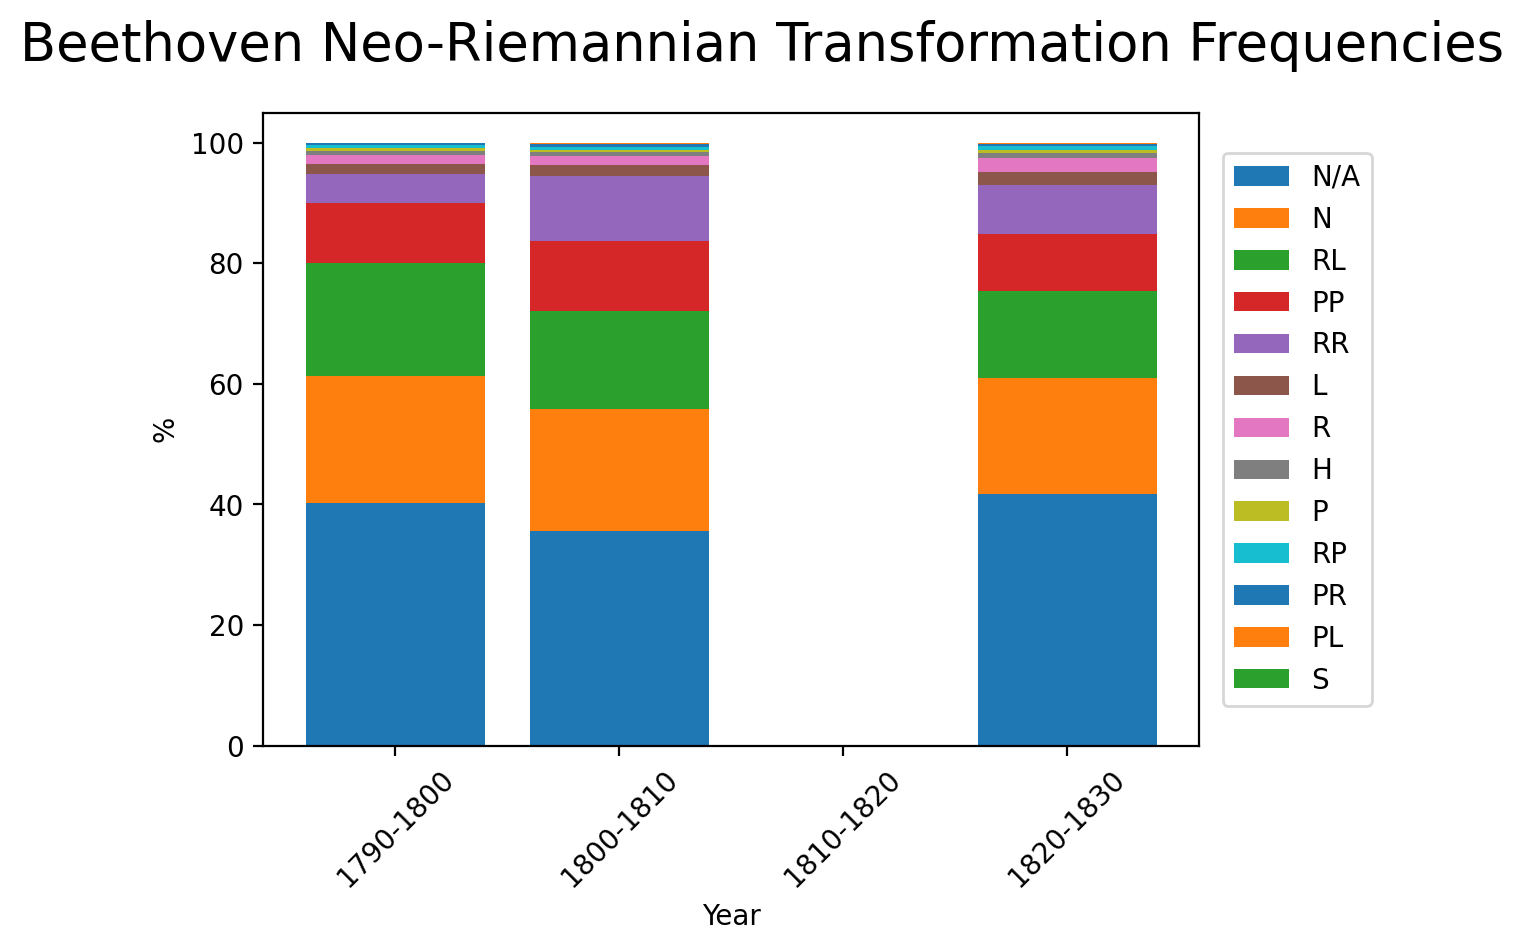

In [577]:
x = beeth_bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)
counts = beethoven_transformations.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
tot_counts = (
    beethoven_transformations.groupby('year_bin')
    .size()
    .reindex(x, fill_value=0)
)

for trans in beethoven_transformations.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = beethoven_transformations[beethoven_transformations['transformation']== trans]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y) * 100/tot_counts

    ax.bar(x, y, bottom = current_itn, label=trans)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Beethoven Neo-Riemannian Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.savefig(f"../Results/Beeth_Transformations")
plt.show()

## Entire Corpus

In [588]:
classical_metadata = pd.read_csv("/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/dcml_corpora.metadata.tsv", sep='\t')

In [596]:
classical = []
for _, row in classical_metadata.iterrows():
    corpus = row['corpus']
    piece = row['piece']
    path = f'/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/harmonies/{piece}.harmonies.tsv'
    
    try:
        piece_df = pd.read_csv(path, sep='\t')
        piece_df['corpus'] = corpus
        piece_df['piece'] = piece
        piece_df['year'] = row['composed_start']
        classical.append(piece_df)
    except:
        continue

classical = pd.concat(classical, ignore_index=True)

In [661]:
bins = [
    1600,  # Start of Baroque
    1750,  # End of Baroque
    1830,  # End of Classical
    1900,  # End of Romantic
    2000   # End of 20th Century
]
bin_labels = [
    '1600–1750',
    '1750–1830',
    '1830–1900',
    '1900–2000'
]
classical['year'] = pd.to_numeric(classical['year'], errors='coerce')
classical['year_bin'] = pd.cut(classical['year'], bins=bins, labels=bin_labels, right=False)

classical_metadata['year'] = pd.to_numeric(classical_metadata['composed_start'], errors='coerce')
classical_metadata['year_bin'] = pd.cut(classical_metadata['year'], bins=bins, labels=bin_labels, right=False)

In [620]:
classical_updated, classical_exceptions = update_chord_labels(classical)

In [631]:
classical_transformations, classical_transform_exceptions = transformation(classical_updated)

In [636]:
classical_transformations_cut = classical_transformations[classical_transformations['transformation'] != 'N/A'].copy()

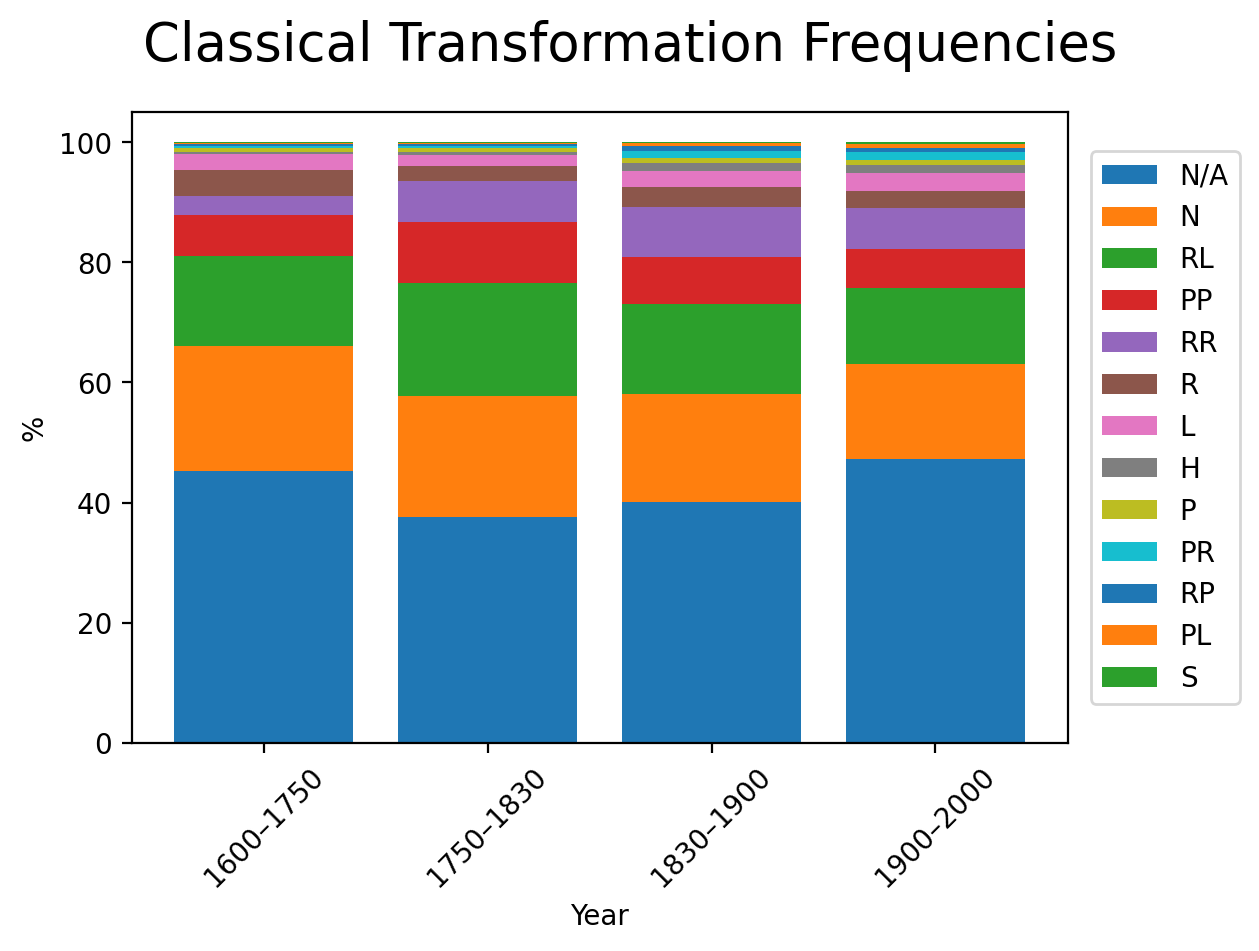

In [671]:
x = bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)
counts = classical_transformations.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
tot_counts = (
    classical_transformations.groupby('year_bin')
    .size()
    .reindex(x, fill_value=0)
)

for trans in classical_transformations.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = classical_transformations[classical_transformations['transformation']== trans]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y) * 100/tot_counts

    ax.bar(x, y, bottom = current_itn, label=trans)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Classical Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.savefig(f"../Results/Classical_Transformations")
plt.show()

## Tonnetz

In [649]:
classical_metadata['corpus'].unique()

array(['ABC', 'beethoven_piano_sonatas', 'chopin_mazurkas', 'corelli',
       'debussy_suite_bergamasque', 'dvorak_silhouettes',
       'grieg_lyric_pieces', 'liszt_pelerinage', 'medtner_tales',
       'mozart_piano_sonatas', 'schumann_kinderszenen',
       'tchaikovsky_seasons'], dtype=object)

In [655]:
for corpus in classical_metadata['corpus'].unique():
    input_folder = Path(f"/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/MS3")
    output_folder = Path(f"/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/MXL")

    mscore_path = "/Applications/MuseScore 4.app/Contents/MacOS/mscore"
    output_folder.mkdir(exist_ok=True)
    
    # Convert all .mscx files in input_folder to .mxl in output_folder
    for mscx_file in input_folder.rglob("*.mscx"):
        output_file = output_folder / (mscx_file.stem + ".mxl")
        subprocess.run([
            mscore_path,
            str(mscx_file),
            "-o", str(output_file)
        ], stderr=subprocess.DEVNULL)

In [647]:
import pitchplots.parser as ppp
import pitchplots.static as pps
import subprocess
from pathlib import Path

path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/beethoven_piano_sonatas/MS3/10-2.mscx'
path_mxl = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/beethoven_piano_sonatas/MXL/10-2.mxl'

input_folder = Path(path)
output_folder = Path(path_mxl)
output_folder.mkdir(exist_ok=True)

for mscx_file in input_folder.rglob("*.mscx"):
    output_file = output_folder / (mscx_file.stem + ".mxl")
    subprocess.run([
        "mscore4",  # or "mscore" / "musescore4"
        str(mscx_file),
        "-o", str(output_file)
    ])

df = ppp.xml_to_csv(path_mxl, save_csv=False)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/beethoven_piano_sonatas/MXL/10-2'

KeyError: 'year_bin'

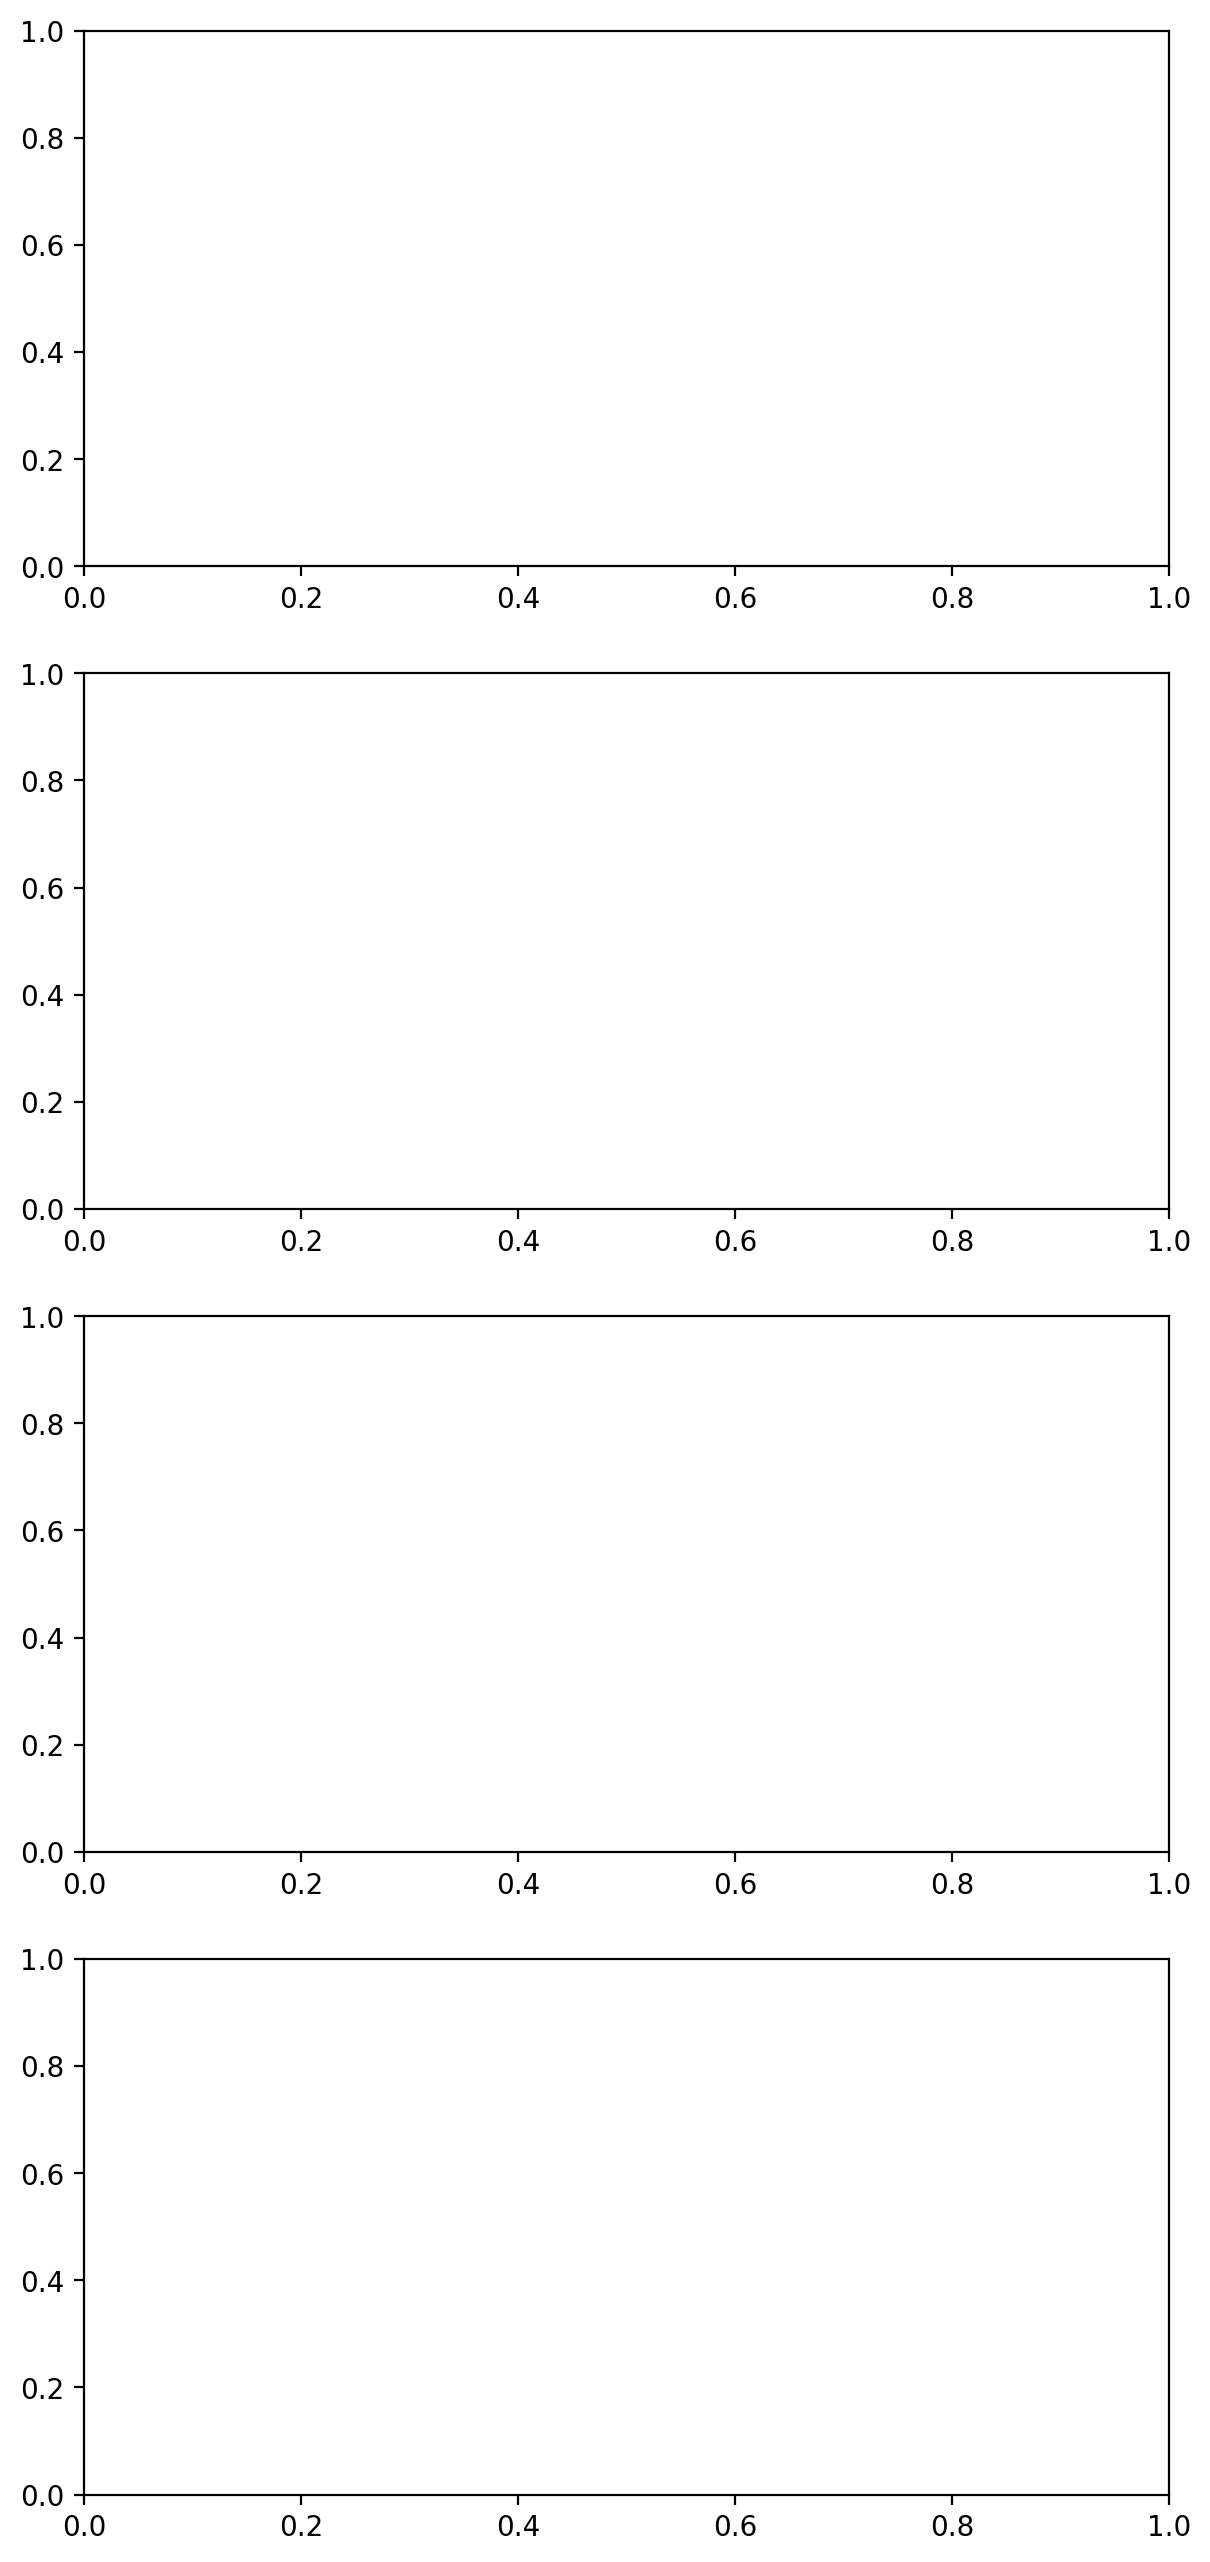

In [657]:
n_bins = len(bin_labels)
fig, axes = plt.subplots(n_bins, 1, figsize=(7, n_bins * 4))
if n_bins == 1:
    axes = [axes]  

for ax, years in zip(axes, bin_labels):
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try:
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/MXL/{piece}.mxl/' 
            path = f"{base_path}{row['rel_paths']}/{row['fnames']}.xml"

            df = ppp.xml_to_csv(path, save_csv=False)
            notes_tonnetz = pd.concat([notes_tonnetz, df], ignore_index=True)

        except Exception:
            continue

    notes_tonnetz = notes_tonnetz.dropna(subset=['tpc'])
    notes_tonnetz['tpc'] = (notes_tonnetz['tpc'].str.replace('x', '##'))

    fig_tmp = pps.tonnetz(notes_tonnetz, show=False)

    buf = io.BytesIO()
    fig_tmp.savefig(buf, format='png', dpi=150)
    buf.seek(0)
    img = Image.open(buf)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Year Bin: {years}", fontsize=12)

plt.tight_layout()
plt.savefig("Classical_tonnetz.png", dpi=300)
plt.show()

## Pitch Profile

In [770]:
import ms3
def get_key(row_harm):
    try:
        tonic = row_harm['globalkey']
        mode = 'minor' if row_harm['globalkey_is_minor'] == 1 else 'major'
        k = m21.key.Key(tonic, mode)
        
        local_key_raw = row_harm['localkey']
        local_mode = 'minor' if row_harm['localkey_is_minor'] == 1 else 'major'
    
        local_key_chord = m21.roman.RomanNumeral(local_key_raw, k)
        local_tonic = local_key_chord.root()
    
        key = m21.key.Key(local_tonic, local_mode)
        return str(key)
    except Exception:
        return np.nan
            
def load_notes(metadata, keys=False):

    dfs = []
    for _, row in metadata.iterrows():
        corpus = row['corpus']
        piece = row['piece']
        
        notes_path = f"/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/notes/{piece}.notes.tsv"
        
        try: 
            df_notes = pd.read_csv(notes_path, sep='\t')
            df_notes['mc'] = df_notes['mc'].astype(int)

            df_notes['pc'] = df_notes['midi'] % 24
            df_notes['pc'] = df_notes['pc'].apply(int)

            df_notes['note'] = df_notes['tpc'].apply(ms3.tpc2name)
            df_notes['note'] = df_notes['note'].apply(g.fix_flats)
        
            df_notes['mc_onset'] = df_notes['mc_onset'].astype(str).apply(lambda x: float(Fraction(x)))
            df_notes['duration'] = df_notes['duration'].astype(str).apply(lambda x: float(Fraction(x)))
            df_notes['time'] = df_notes['mc'] + df_notes['mc_onset']

            df_notes['corpus'] = corpus
            df_notes['piece'] = piece
            df_notes['recording_year'] = row['composed_start']

            df_notes = df_notes.sort_values(by='time')

            if keys:
                harm_path = f'/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/harmonies/{piece}.harmonies.tsv'
                df_harm = pd.read_csv(harm_path, sep='\t')
                df_harm['key'] = df_harm.apply(get_key, axis=1)
                df_harm['mc_onset'] = df_harm['mc_onset'].astype(str).apply(lambda x: float(Fraction(x)))
                df_harm['duration_qb'] = df_harm['duration_qb'].astype(str).apply(lambda x: float(Fraction(x)))
                df_harm['time'] = df_harm['mc'] + df_harm['mc_onset']

                df_harm = df_harm.sort_values(by='time')
                
                df_notes = df_notes.merge(df_harm[['time','key']], on='time', how='left')
                df_notes['key'] = df_notes['key'].ffill()
                    
            dfs.append(df_notes)

        except Exception as e:
            #print(f'{e}')
            continue
    
    dfs = pd.concat(dfs, ignore_index=True)
    
    return dfs

In [772]:
notes = load_notes(classical_metadata, keys=True)


In [773]:
notes

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,...,chord_id,pc,note,time,corpus,piece,recording_year,key,tremolo,volta
0,1,1,0,0,1.0,0.00,0,3/4,3,1,...,12,5,F,1.00,ABC,n01op18-1_01,1799,F major,NaN,NaN
1,1,1,0,0,1.0,0.00,0,3/4,4,1,...,18,5,F,1.00,ABC,n01op18-1_01,1799,F major,NaN,NaN
2,1,1,0,0,1.0,0.00,0,3/4,1,1,...,0,17,F,1.00,ABC,n01op18-1_01,1799,F major,NaN,NaN
3,1,1,0,0,1.0,0.00,0,3/4,2,1,...,6,17,F,1.00,ABC,n01op18-1_01,1799,F major,NaN,NaN
4,1,1,1,1,0.5,0.25,1/4,3/4,3,1,...,13,5,F,1.25,ABC,n01op18-1_01,1799,F major,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
652427,176,176,525,525,1.0,0.00,0,3/4,2,1,...,1071,3,E-,176.00,tchaikovsky_seasons,op37a12,1875,A- major,NaN,NaN
652428,176,176,525,525,1.0,0.00,0,3/4,1,1,...,1070,12,C,176.00,tchaikovsky_seasons,op37a12,1875,A- major,NaN,NaN
652429,176,176,525,525,1.0,0.00,0,3/4,2,1,...,1071,20,A-,176.00,tchaikovsky_seasons,op37a12,1875,A- major,NaN,NaN
652430,176,176,525,525,1.0,0.00,0,3/4,2,1,...,1071,0,C,176.00,tchaikovsky_seasons,op37a12,1875,A- major,NaN,NaN


In [776]:
notes_C = pa.transpose_to_C(notes)
notes_C = notes_C[notes_C['transposed note'].notna()]

In [782]:
subset_year = notes_C[notes_C['recording_year'].notna()].copy()
subset_year['year_bin'] = pd.cut(subset_year['recording_year'], bins=bins, labels=bin_labels, right=False)

In [784]:
identifier = ['year_bin']
subset_year = subset_year.groupby(identifier, as_index=False).agg(list)

In [785]:
data_year = pa.create_data(subset_year, identifier)

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_93475/3386628780.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors


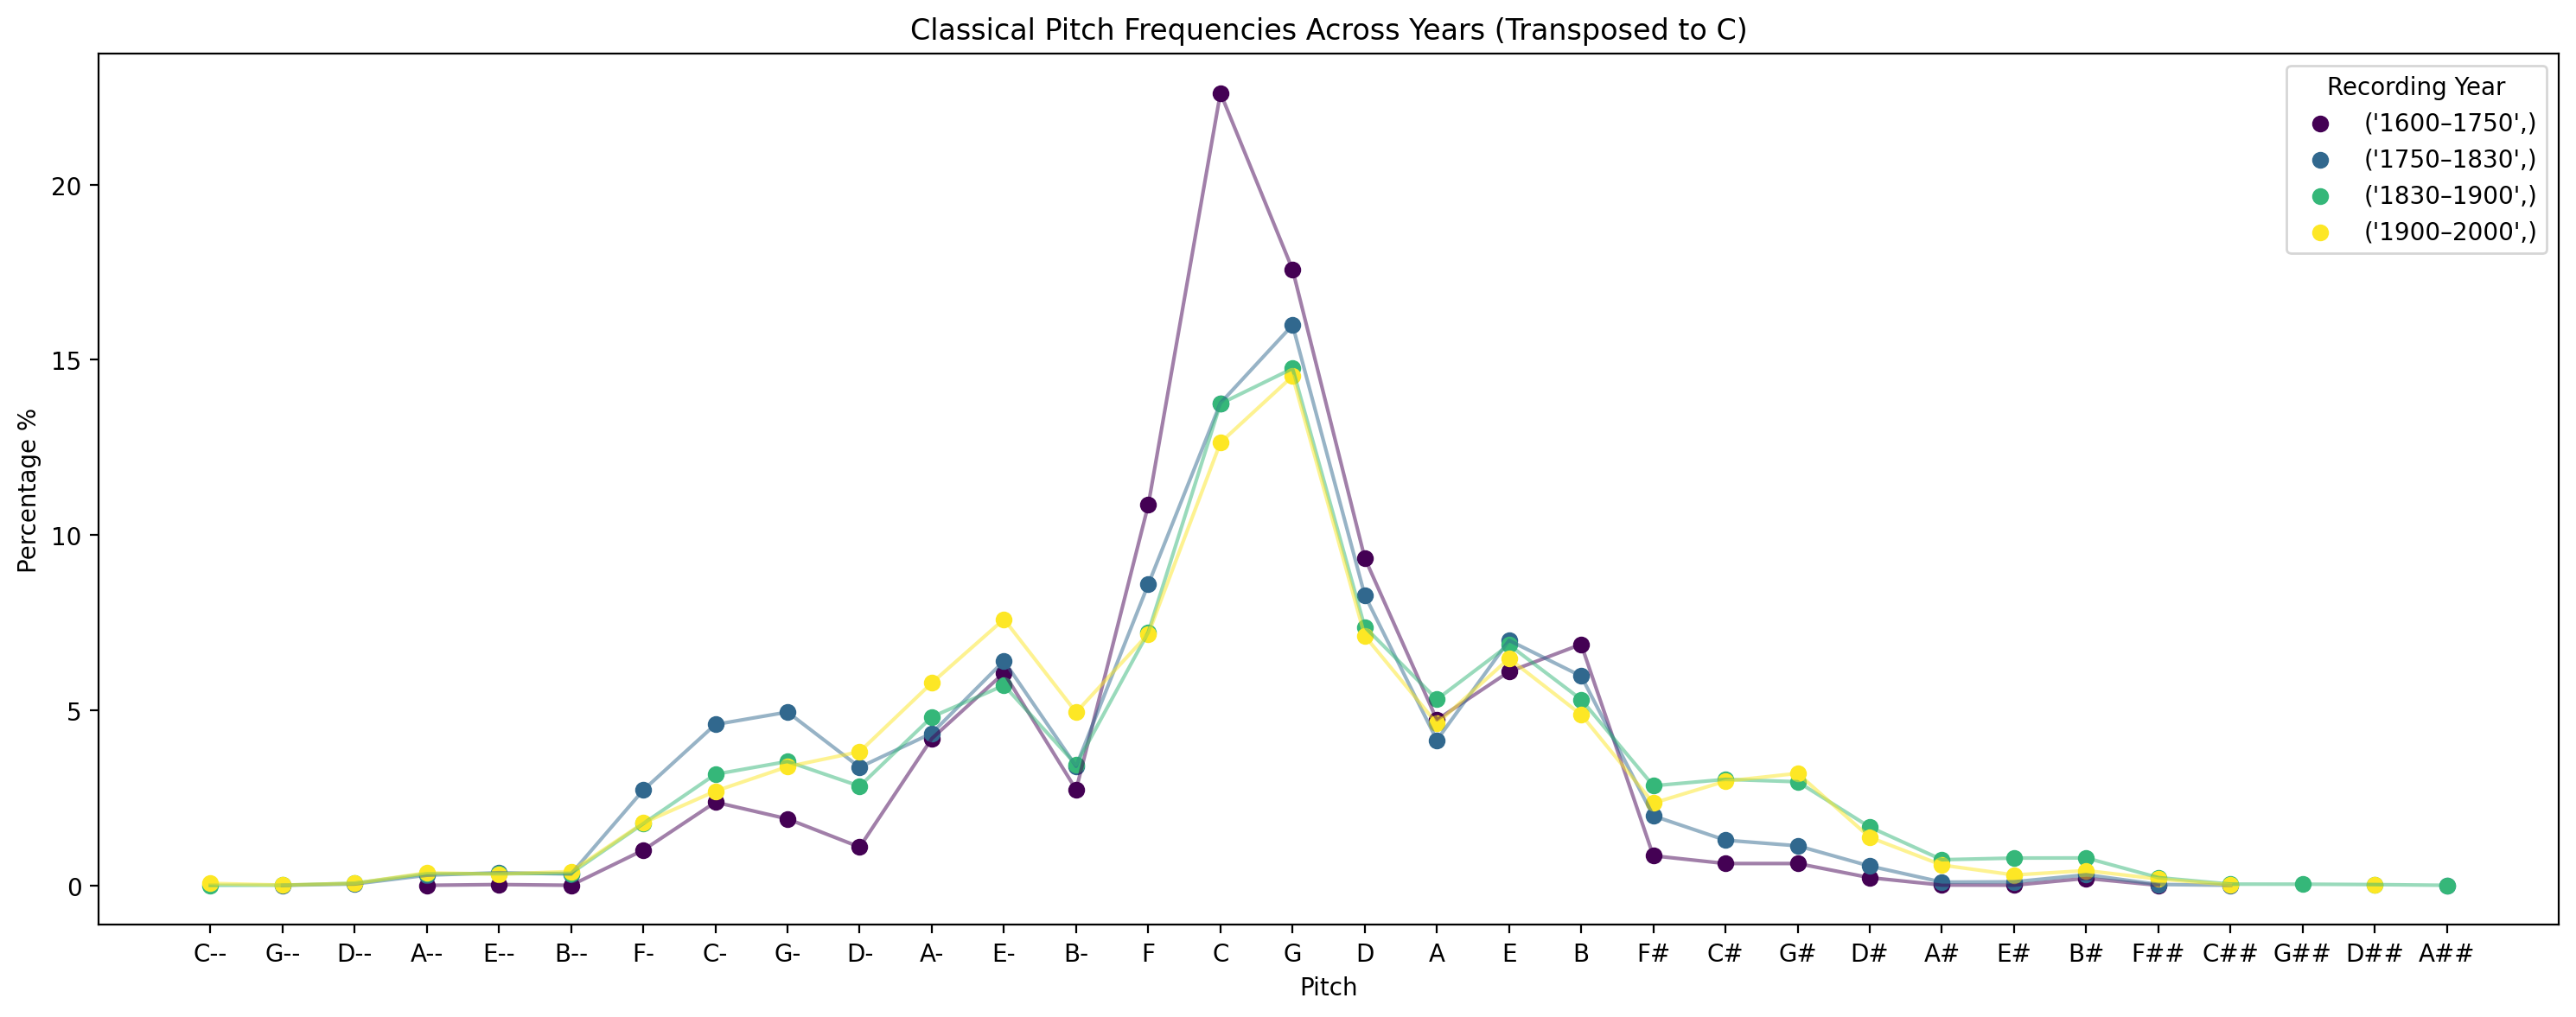

In [821]:
full_range = pd.DataFrame({
    'transposed tpc': range(
        int(notes_C['transposed tpc'].min()),
        int(notes_C['transposed tpc'].max()) + 1  # include max
    )
})

keys = list(data_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors

for i, key in enumerate(keys):

    # Get the pitch profile data
    pitch_data = data_year[key]
    tpc = pd.DataFrame({
        'transposed note': pitch_data['transposed note'],
        'transposed tpc': pitch_data['transposed tpc'],
        'duration': pitch_data['duration']
    })

    pitch_counts = tpc.groupby(['transposed note', 'transposed tpc'])['duration'].sum().reset_index(name='weighted_count')
    count = pitch_counts.sort_values('transposed tpc')
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    count = full_range.merge(count, on='transposed tpc', how='left')
    count['transposed note'] = count['transposed tpc'].apply(pa.get_note)

    ax.plot(count['transposed note'], count['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(count['transposed note'],count['percentage'], label=key, color=colors(i))

ax.set_xlabel('Pitch')
ax.set_ylabel('Percentage %')
ax.set_title(f'Classical Pitch Frequencies Across Years (Transposed to C)')
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/0823_YearTransposedPitchOverlayClassical")
plt.show()